In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-09-10 09:48:07.587070: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-10 09:48:07.937937: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-10 09:48:12.847059: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
datasetPath = "dataset/10p/all/kernel3/"

In [4]:
# Parameters
datasetPath = "dataset/10p/ngtdm/kernel3/"


In [5]:
# train/validation/test = 70/10/20
train_data = pd.read_csv(f"{datasetPath}dataset.train.csv")
validation_data = pd.read_csv(f"{datasetPath}dataset.validation.csv")
test_data = pd.read_csv(f"{datasetPath}dataset.test.csv")

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-09-10 09:48:26.528763: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-10 09:48:26.529936: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
import keras

In [8]:
%%time

# Train a Gradient Boosted Trees model.
model = tfdf.keras.GradientBoostedTreesModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmpqtxt9snt as temporary training directory


Reading training dataset...


[WARNING 26-09-10 09:48:26.6586 UTC gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 26-09-10 09:48:26.6588 UTC gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 26-09-10 09:48:26.6588 UTC gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Training dataset read in 0:00:02.767102. Found 29597 examples.


Training model...


Model trained in 0:00:01.414280


Compiling model...


[INFO 26-09-10 09:48:30.8675 UTC kernel.cc:1233] Loading model from path /tmp/tmpqtxt9snt/model/ with prefix bffd15b404d446eb
[INFO 26-09-10 09:48:30.8720 UTC quick_scorer_extended.cc:911] The binary was compiled without AVX2 support, but your CPU supports it. Enable it for faster model inference.
[INFO 26-09-10 09:48:30.8724 UTC abstract_model.cc:1362] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 26-09-10 09:48:30.8724 UTC kernel.cc:1061] Use fast generic engine


Model compiled.


CPU times: user 9.91 s, sys: 529 ms, total: 10.4 s
Wall time: 7.66 s


In [9]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

1/5 [=====>........................] - ETA: 12s - loss: 0.0000e+00 - accuracy: 0.9010

5/5 [==============================] - 3s 4ms/step - loss: 0.0000e+00 - accuracy: 0.9077



loss: 0.0000
accuracy: 0.9077


In [10]:
# Model Summary
model.summary()

Model: "gradient_boosted_trees_model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


Total params: 1 (1.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 1 (1.00 Byte)


_________________________________________________________________


Type: "GRADIENT_BOOSTED_TREES"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (5):
	Busyness
	Coarseness
	Complexity
	Contrast
	Strength

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.   "Busyness"  0.783455 ################
    2. "Complexity"  0.242627 
    3.   "Contrast"  0.222249 
    4.   "Strength"  0.219597 
    5. "Coarseness"  0.212573 

Variable Importance: NUM_AS_ROOT:
    1.   "Busyness" 61.000000 ################
    2. "Coarseness"  6.000000 #
    3.   "Contrast"  1.000000 

Variable Importance: NUM_NODES:
    1.   "Busyness" 572.000000 ################
    2.   "Strength" 341.000000 ####
    3.   "Contrast" 337.000000 ####
    4. "Complexity" 325.000000 ###
    5. "Coarseness" 257.000000 

Variable Importance: SUM_SCORE:
    1.   "Busyness" 17577.222418 ################
    2. "Complexity" 2912.347309 #
    3.   "Contrast" 2329.468406 #
    4.   "Strength" 1909.876558 
    5. "Coarseness" 1240.775441 



Loss: BINOMIAL_LOG_LIKELIHOOD
Valida

In [11]:
# Model features
model.make_inspector().features()

["Busyness" (1; #0),
 "Coarseness" (1; #1),
 "Complexity" (1; #2),
 "Contrast" (1; #3),
 "Strength" (1; #4)]

In [12]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Busyness" (1; #0), 0.7834554270919954),
  ("Complexity" (1; #2), 0.24262745714382136),
  ("Contrast" (1; #3), 0.22224895302117778),
  ("Strength" (1; #4), 0.21959685068821852),
  ("Coarseness" (1; #1), 0.212573346851642)],
 'SUM_SCORE': [("Busyness" (1; #0), 17577.222417538484),
  ("Complexity" (1; #2), 2912.3473091295027),
  ("Contrast" (1; #3), 2329.4684064399703),
  ("Strength" (1; #4), 1909.8765584137138),
  ("Coarseness" (1; #1), 1240.775441146619)],
 'NUM_AS_ROOT': [("Busyness" (1; #0), 61.0),
  ("Coarseness" (1; #1), 6.0),
  ("Contrast" (1; #3), 1.0)],
 'NUM_NODES': [("Busyness" (1; #0), 572.0),
  ("Strength" (1; #4), 341.0),
  ("Contrast" (1; #3), 337.0),
  ("Complexity" (1; #2), 325.0),
  ("Coarseness" (1; #1), 257.0)]}

In [13]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=None, accuracy=0.8799690008163452, loss=0.5603655576705933, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

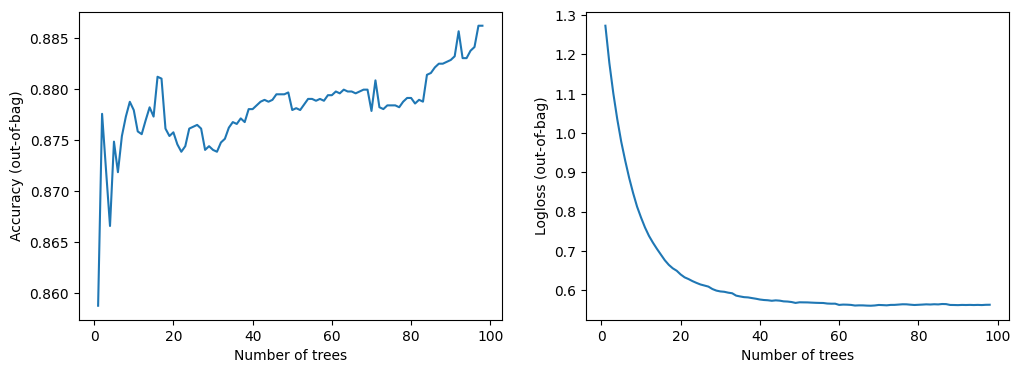

In [14]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

1/5 [=====>........................] - ETA: 0s

5/5 [==============================] - 0s 2ms/step


The ROC AUC score is 0.97433


In [16]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

1/9 [==>...........................] - ETA: 0s

9/9 [==============================] - 0s 2ms/step


Sklearn binary metrics:
accuracy: 0.9524
precision: 0.7328
recall: 0.8199
f1: 0.7739
mcc: 0.7489
roc_auc: 0.9482
pr_auc: 0.8175
log_loss: 0.1899
brier_score: 0.0467

Confusion matrix:
 [[7747  264]
 [ 159  724]]

Classification report:
               precision    recall  f1-score   support

           0     0.9799    0.9670    0.9734      8011
           1     0.7328    0.8199    0.7739       883

    accuracy                         0.9524      8894
   macro avg     0.8563    0.8935    0.8737      8894
weighted avg     0.9554    0.9524    0.9536      8894

